Numpy-Numeric Python -Array values
We can mathematical or Statistical Calculation
1d-[],2d-[[]],3d-[[[]]]
[r,c]-size,shape,len,ndim
Built in functions
arange-(1,10,2),linspace-(10,45,10)-50 elements,random.rand(1,10),randn-(-3 to +3),randint-INt data
zeros,ones,Broadcasting,Check conditions
where-retrieve index number,sum,avg,mean,median

Pandas-Data Analysis -to understand the data
Series-One Dimensional Data Structure
DataFrame-Multidimensional array
shape,iloc-row,loc-bases on condition it will retireve ur output
info,columns,isnull().sum(),drop-column-axis=1,row-axis=0,
groupby,describe-numerical and categorical,ascending=False,sort,df[[]]

Seaborn-Data visualization
Univariate Analysis-countplot,hisplot
Bivariate analysis-violinplot,barplot,scatterplot,lineplot
Multivariate Analysis-pairplot

In [1]:
#Load the libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#Read the csv file
df=pd.read_csv("Advertising.csv")

In [18]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,NaN,69.2,22.1
1,2,44.5,NaN,45.1,10.4
2,3,17.2,NaN,69.3,9.3
3,4,151.5,NaN,58.5,18.5
4,5,180.8,NaN,58.4,12.9


In [19]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,195.000000,200.000000,200.000000
mean,100.500000,147.042500,22.962564,30.554000,14.022500
std,57.879185,85.854236,14.781208,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.750000,12.750000,10.375000
50%,100.500000,149.750000,22.300000,25.750000,12.900000
75%,150.250000,218.825000,35.700000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


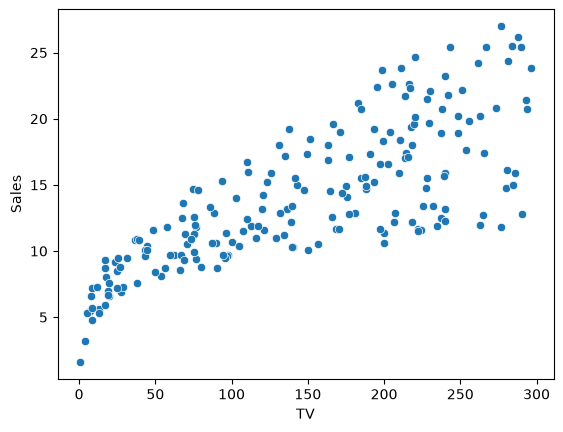

In [20]:
sns.scatterplot(x="TV",y="Sales",data=df)
plt.show()

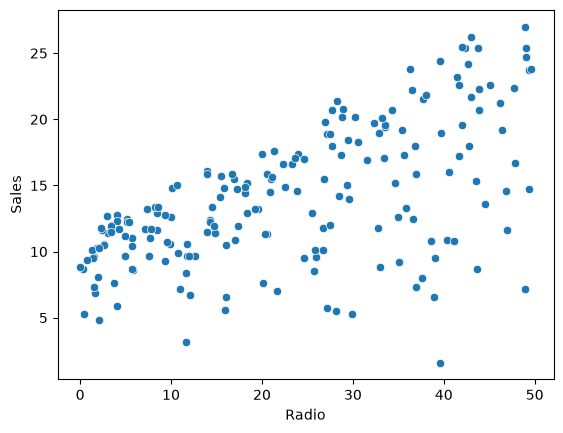

In [21]:
sns.scatterplot(x="Radio",y="Sales",data=df)
plt.show()

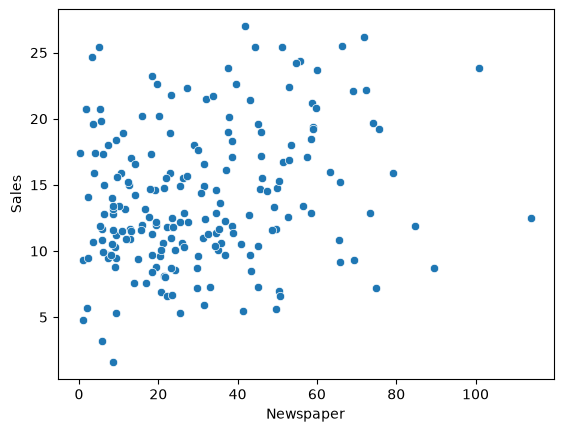

In [22]:
sns.scatterplot(x="Newspaper",y="Sales",data=df)
plt.show()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       195 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [24]:
#Data Preprocessing
#Check null values
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         5
Newspaper     0
Sales         0
dtype: int64

In [25]:
#Null values is there we need to find mean values of particular column
radio=np.mean(df['Radio'])
radio

np.float64(22.962564102564105)

In [26]:
df['Radio'].fillna(radio,inplace=True)

C:\Users\mails\AppData\Local\Temp\ipykernel_10692\2103516797.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Radio'].fillna(radio,inplace=True)


In [27]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,22.962564,69.2,22.1
1,2,44.5,22.962564,45.1,10.4
2,3,17.2,22.962564,69.3,9.3
3,4,151.5,22.962564,58.5,18.5
4,5,180.8,22.962564,58.4,12.9


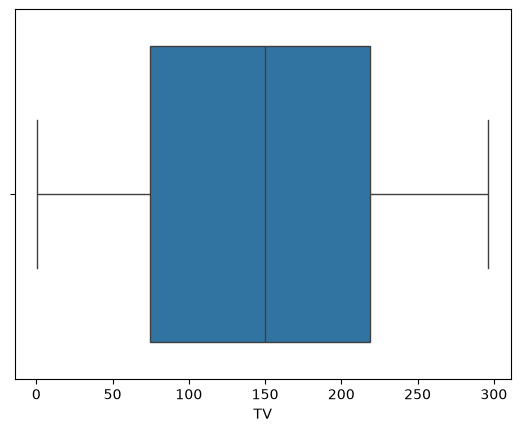

In [28]:
#Check outliers
sns.boxplot(x="TV",data=df)
plt.show()

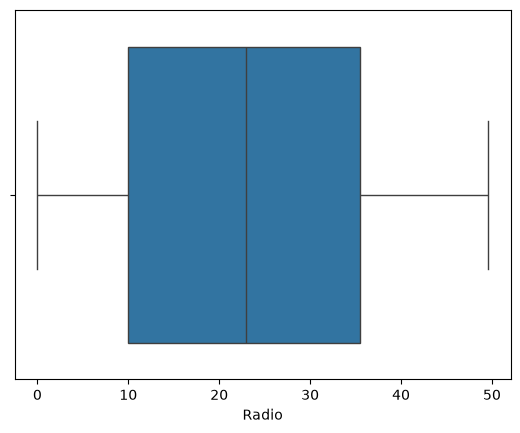

In [29]:
sns.boxplot(x="Radio",data=df)
plt.show()

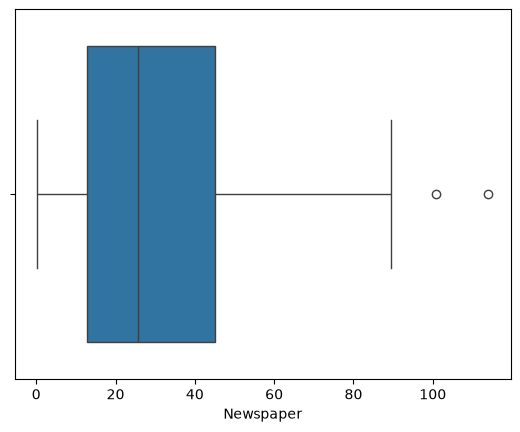

In [30]:
sns.boxplot(x="Newspaper",data=df)
plt.show()

In [31]:
Q1=df['Newspaper'].quantile(0.25)
Q3=df['Newspaper'].quantile(0.75)

In [32]:
Q1,Q3

(np.float64(12.75), np.float64(45.1))

In [33]:
#Find IQR
IQR=Q3-Q1

In [34]:
IQR

np.float64(32.35)

In [35]:
#Find Upper Limit and Lower Limit
upper_limit=Q3+1.5*IQR
lower_limit=Q1-1.5*IQR

In [36]:
upper_limit,lower_limit

(np.float64(93.625), np.float64(-35.775000000000006))

In [37]:
df.loc[df['Newspaper']<lower_limit]#No outliers in the lower limit

,Unnamed: 0,TV,Radio,Newspaper,Sales


In [39]:
df.loc[df['Newspaper']>upper_limit]#U have data points outliers in upper limit

,Unnamed: 0,TV,Radio,Newspaper,Sales
16,17,67.8,36.6,114.0,12.5
101,102,296.4,36.3,100.9,23.8


In [40]:
df.loc[df['Newspaper']>upper_limit]=df['Newspaper'].mean() #Replace the outliers data to mean values

C:\Users\mails\AppData\Local\Temp\ipykernel_10692\1454446551.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30.553999999999995' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Newspaper']>upper_limit]=df['Newspaper'].mean()


In [41]:
df.loc[df['Newspaper']>upper_limit]

,Unnamed: 0,TV,Radio,Newspaper,Sales


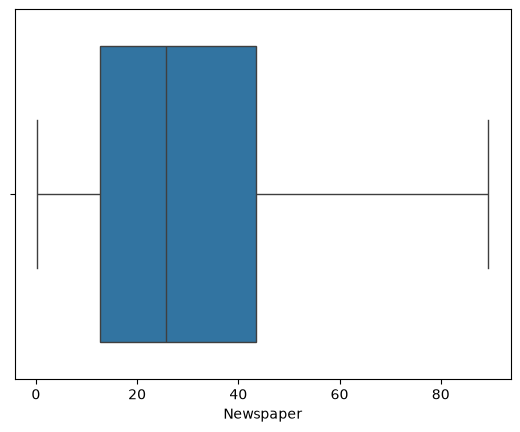

In [42]:
sns.boxplot(x="Newspaper",data=df)
plt.show()

In [43]:
df[0:3]

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1.0,230.1,22.962564,69.2,22.1
1,2.0,44.5,22.962564,45.1,10.4
2,3.0,17.2,22.962564,69.3,9.3


In [ ]:
#Feature Selection

In [44]:
df[0:3]

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1.0,230.1,22.962564,69.2,22.1
1,2.0,44.5,22.962564,45.1,10.4
2,3.0,17.2,22.962564,69.3,9.3


In [45]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [46]:
df[0:3]

,TV,Radio,Newspaper,Sales
0,230.1,22.962564,69.2,22.1
1,44.5,22.962564,45.1,10.4
2,17.2,22.962564,69.3,9.3


In [48]:
#Correlation
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.060193,0.048801,0.694187
Radio,0.060193,1.000000,0.319579,0.571165
Newspaper,0.048801,0.319579,1.000000,0.210282
Sales,0.694187,0.571165,0.210282,1.000000


<Axes: >

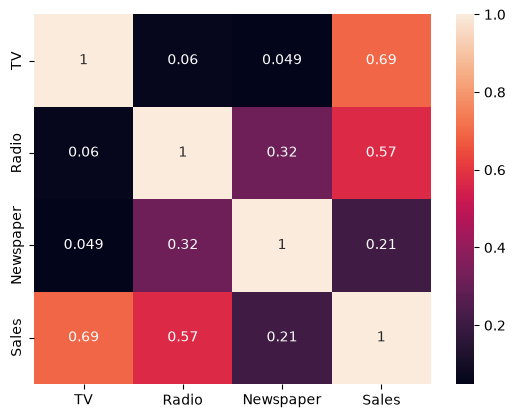

In [54]:
sns.heatmap(df.corr(),annot=True)

In [50]:
#Split the data
x=df.drop("Sales",axis=1)
y=df["Sales"]

In [51]:
x[0:3]

,TV,Radio,Newspaper
0,230.1,22.962564,69.2
1,44.5,22.962564,45.1
2,17.2,22.962564,69.3


In [52]:
y[0:2]

0    22.1
1    10.4
Name: Sales, dtype: float64

In [55]:
#Split train_data and test data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
#Training size=70% and Test size=30%

In [56]:
df.shape

(200, 4)

In [57]:
#Train the model and test the model
x_train.shape,x_test.shape

((140, 3), (60, 3))

In [58]:
x_train[0:3],y_train[0:3]

(        TV  Radio  Newspaper
 169  284.3   10.6        6.4
 97   184.9   21.0       22.0
 31   112.9   17.4       38.6,
 169    15.0
 97     15.5
 31     11.9
 Name: Sales, dtype: float64)

In [59]:
x_test[0:3],y_test[0:3]

(       TV  Radio  Newspaper
 95  163.3   31.6       52.9
 15  195.4   47.7       52.9
 30  292.9   28.3       43.2,
 95    16.9
 15    22.4
 30    21.4
 Name: Sales, dtype: float64)

In [60]:
#Initialize model
from sklearn.linear_model import LinearRegression
reg=LinearRegression()

In [61]:
#Assign target variable
reg.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.21,0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.142
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [62]:
#Do prediction for test data
pred_sales=reg.predict(x_test)

In [72]:
reg.coef_,reg.intercept_

(array([0.04051977, 0.20740598, 0.01209899]), np.float64(3.1417618602077333))

In [63]:
pred_sales #Predicted o/p

array([16.95270653, 21.59262758, 21.40226921, 11.81599836, 22.26987787,
       14.08162306, 21.36066393,  7.79628136, 13.01703658, 15.28452701,
        9.54693968,  6.96052726, 14.37482349,  9.67573804,  9.55165597,
       12.08187844,  9.76656255, 16.15283415, 10.79645945, 18.59790949,
       20.03800822, 11.08655798, 13.18395235, 21.75324842,  7.87739096,
        5.98330011, 21.12013663, 11.91696275,  9.43584056,  9.14897857,
       12.03336675, 10.41896436, 22.17293979, 13.97183727, 17.84626808,
       19.97172174, 14.94978953, 20.9483665 , 11.0048818 ,  4.83835431,
        9.71856833, 12.32007093, 10.85057841,  8.50087066, 12.90470972,
        5.62398541,  9.81459242, 14.2984182 ,  8.97854955, 12.13066895,
       16.43442332, 11.59274126, 14.54386077, 12.13811776,  6.5824624 ,
        9.94593305,  9.79789192, 24.27308162,  8.31049252, 11.94577407])

In [66]:
#Evaluation metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [67]:
mean_absolute_error(y_test,pred_sales) #ignore sign and average

1.8371165582819546

In [68]:
mean_squared_error(y_test,pred_sales) #squared error values

10.873154185265633

In [69]:
root_mean_squared_error(y_test,pred_sales)

3.2974466159841973

In [70]:
r2_score(y_test,pred_sales)

0.6643753534844191